Создать обычный заказ из 3 товаров и дисконтный заказ из 2 товаров.
Рассчитать стоимость доставки для каждого обоими способами.
Вывести итоговую цену (товары + доставка).

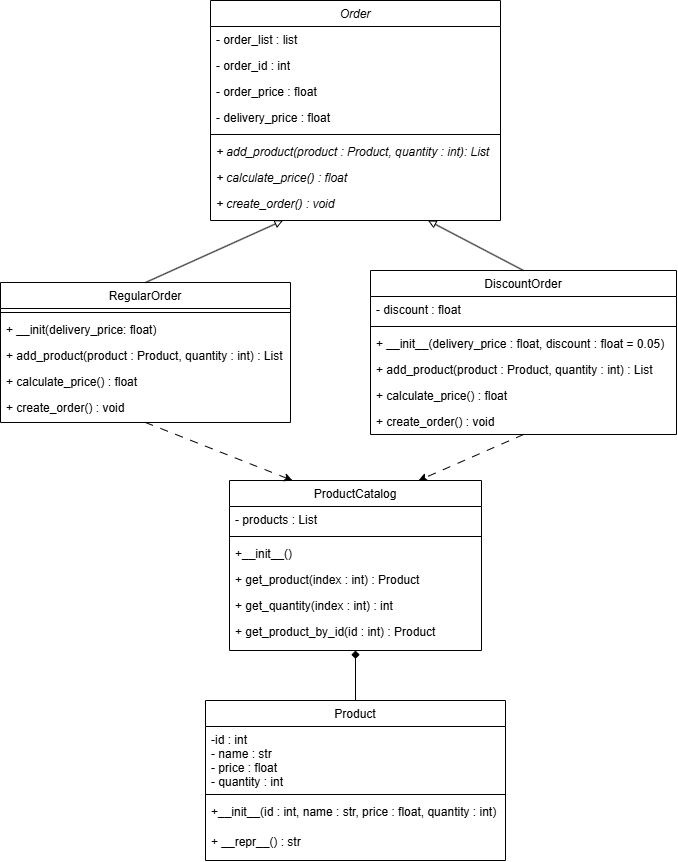

In [1]:
from abc import ABC, abstractmethod
from random import randint

class Order(ABC):

    @abstractmethod
    def add_product(self, index, quantity):
        pass

    @abstractmethod
    def calculate_price(self):
        pass

    @abstractmethod
    def create_order(self):
        pass

class RegularOrder(Order):

    def __init__(self, delivery_price):
        self.order_list = []
        self.order_id = randint(100, 1000)
        self.order_price = 0
        self.delivery_price = delivery_price

    def add_product(self, product, quantity):
        if quantity > 0:
            if product.quantity >= quantity:
                self.order_list.append((product, quantity))
                product.quantity -= quantity
                return self.order_list
            else:
                raise ValueError(f'Количество для заказа должно быть <=, чем имеется на складе. Остаток: {product.name}-{product.quantity}')
        else:
            raise ValueError('Количество должно быть больше нуля!!')


    def calculate_price(self):
        self.order_price = 0
        for product, quantity in self.order_list:
            self.order_price += product.price * quantity
        return self.order_price + self.delivery_price

    def create_order(self):
        print(f'\n\nЗаказ {self.order_id} создан (обычный):')

        for product, quantity in self.order_list:
            cost = product.price * quantity
            print(f'    {product.name} x {quantity} шт = {cost} руб.')

        print(f'Итого: {self.calculate_price()}\n\n')

class DiscountOrder(Order):

    def __init__(self, delivery_price, discount = 0.05):
        self.order_list = []
        self.order_id = randint(100, 1000)
        self.order_price = 0
        self.delivery_price = delivery_price
        self.discount = discount

    def add_product(self, product, quantity):
        if quantity > 0:
            if product.quantity >= quantity:
                self.order_list.append((product, quantity))
                product.quantity -= quantity
                return self.order_list
            else:
                raise ValueError(f'Количество для заказа должно быть <=, чем имеется на складе. Остаток: {product.name}-{product.quantity}')
        else:
            raise ValueError('Количество должно быть больше нуля!!')


    def calculate_price(self):
        self.order_price = 0
        for product, quantity in self.order_list:
            self.order_price += product.price * quantity
        return self.order_price * (1 - self.discount) + self.delivery_price

    def create_order(self):
        print(f'\n\nЗаказ {self.order_id} создан (скидка):')

        for product, quantity in self.order_list:
            cost = product.price * quantity
            print(f'    {product.name} x {quantity} шт = {cost} руб.')

        print(f'Скидка: {self.discount * 100} % = \n'
              f'Итого: {round(self.calculate_price(), 2)}\n\n')

class ProductCatalog:

    def __init__(self):
        self.products = [Product(1, 'гречка', 5, 20),
                         Product(2, 'молоко', 2, 15),
                         Product(3, 'йогурт', 4, 12),
                        ]

    def get_product(self, index):
        return self.products[index]

    def get_quantity(self, index):
        return self.products[index].quantity

    def get_product_by_id(self, id):
        for product in self.products:
            if product.id == id:
                return product
        raise ValueError(f'Товар с id {id} не найден')

class Product:

    def __init__(self, index, name, price, quantity):
        self.id = index
        self.name = name
        self.price = price
        self.quantity = quantity

    def __repr__(self):
        return f"'{self.name}' цена: {self.price} руб., на складе: {self.quantity}"

catalog = ProductCatalog()
ord1 = RegularOrder(20)
# ord1.create_order()
ord1.add_product(catalog.get_product_by_id(1), 1)
ord1.add_product(catalog.get_product_by_id(2), 3)
ord1.add_product(catalog.get_product_by_id(1), 2)
ord1.create_order()

ord2 = DiscountOrder(20)
ord2.add_product(catalog.get_product_by_id(1), 10)
ord2.add_product(catalog.get_product_by_id(2), 3)
ord2.add_product(catalog.get_product_by_id(1), 2)
ord2.create_order()



Заказ 990 создан (обычный):
    гречка x 1 шт = 5 руб.
    молоко x 3 шт = 6 руб.
    гречка x 2 шт = 10 руб.
Итого: 41




Заказ 320 создан (скидка):
    гречка x 10 шт = 50 руб.
    молоко x 3 шт = 6 руб.
    гречка x 2 шт = 10 руб.
Скидка: 5.0 % = 
Итого: 82.7




Задача: Создать библиотеку, 2 читателей, 4 книги.
Один читатель берет 2 книги, другой — 1.
Электронная библиотека выдает 2 электронные книги.
Вывести информацию о библиотеках.

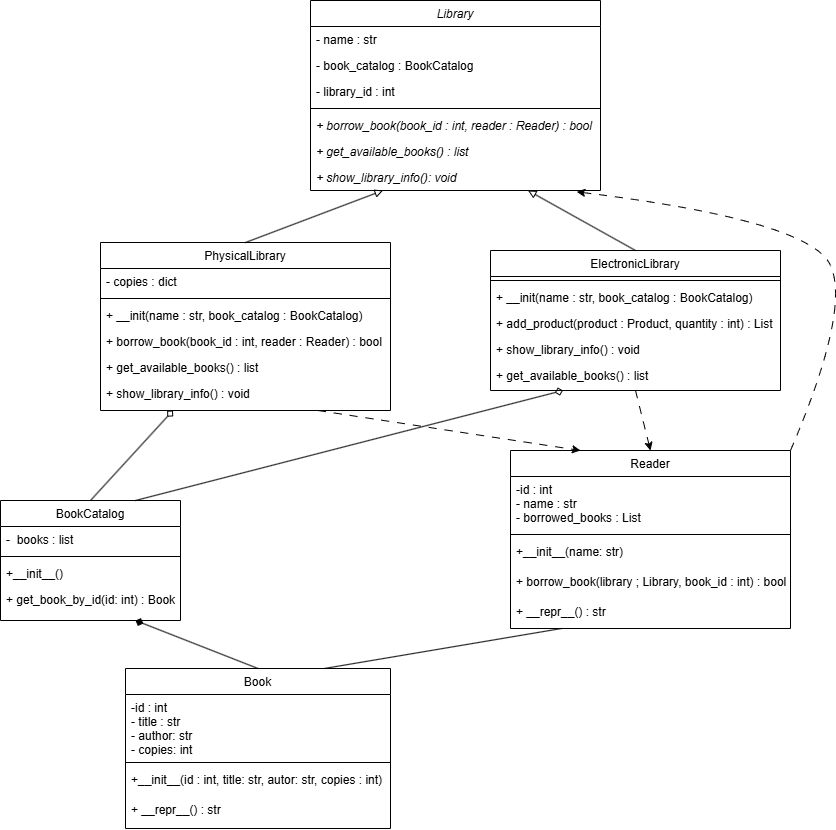

In [2]:
from abc import ABC, abstractmethod
from random import randint

class Library(ABC):
    @abstractmethod
    def borrow_book(self, book_id, reader):
        pass

    @abstractmethod
    def get_available_books(self):
        pass

    @abstractmethod
    def show_library_info(self):
        pass


class PhysicalLibrary(Library):
    def __init__(self, name, book_catalog):
        self.name = name
        self.book_catalog = book_catalog
        self.library_id = randint(100, 1000)
        self.copies = {}
        for book in book_catalog.books:
            self.copies[book.id] = book.copies

    def borrow_book(self, book_id, reader):
        book = self.book_catalog.get_book_by_id(book_id)
        if book:
            if self.copies.get(book_id, 0) > 0:
                self.copies[book_id] -= 1
                reader.borrowed_books.append(book)
                print(f"Читатель {reader.name} взял '{book.title}'")
                return True
            else:
                print(f"Книги '{book.title}' нет в наличии")
                return False
        print(f"Книга с id {book_id} не найдена")
        return False

    def get_available_books(self):
        available = []
        for book in self.book_catalog.books:
            if self.copies.get(book.id, 0) > 0:
                available.append(book)
        return available

    def show_library_info(self):
        print(f'\n\nБиблиотека "{self.name}" ID: {self.library_id}:')
        print("Доступные книги (физические):")
        for book in self.book_catalog.books:
            print(f"{book} - {self.copies.get(book.id, 0)} экз.")


class ElectronicsLibrary(Library):
    def __init__(self, name, book_catalog):
        self.name = name
        self.book_catalog = book_catalog
        self.library_id = randint(100, 1000)

    def borrow_book(self, book_id, reader):
        book = self.book_catalog.get_book_by_id(book_id)
        if book:
            reader.borrowed_books.append(book)
            print(f"{reader.name} взял электронную книгу '{book.title}'")
            return True
        print(f"Электронная книга с id = {book_id} не найдена")
        return False

    def get_available_books(self):
        return self.book_catalog.books.copy()

    def show_library_info(self):
        print(f'\n\nЭлектронная библиотека "{self.name}" ID: {self.library_id}:')
        print("Доступные электронные книги:")
        for book in self.book_catalog.books:
            print(f"    {book}")


class BookCatalog:
    def __init__(self):
        self.books = [
            Book(1, 'Унесённые ветром', 'Маргарет Митчелл', 4),
            Book(2, 'Маленький принц', 'Антуан де Сент-Экзюпери', 6),
            Book(3, 'Преступление и наказание', 'Фёдор Достоевский', 2),
            Book(4, 'Сто лет одиночества', 'Габриэль Гарсиа Маркес', 1)
        ]

    def get_book_by_id(self, id):
        for book in self.books:
            if book.id == id:
                return book
        raise ValueError(f'Книга с id {id} не найдена')


class Book:
    def __init__(self, id, title, author, copies):
        self.id = id
        self.title = title
        self.author = author
        self.copies = copies

    def __repr__(self):
        return f"'{self.title}' {self.author}"


class Reader:
    def __init__(self, name):
        self.id = randint(100000, 999999)
        self.name = name
        self.borrowed_books = []

    def borrow_book(self, library, book_id):
        return library.borrow_book(book_id, self)

    def __repr__(self):
        return f"Читатель: {self.name} ID: {self.id}"


physical_catalog = BookCatalog()
physical_lib = PhysicalLibrary("Городская библиотека", physical_catalog)
physical_lib.show_library_info()

digital_catalog = BookCatalog()
digital_lib = ElectronicsLibrary("Электронная библиотека", digital_catalog)
digital_lib.show_library_info()


reader1 = Reader('Мария')
reader2 = Reader("Марат")


reader1.borrow_book(physical_lib, 1)
reader1.borrow_book(physical_lib, 3)
reader1.borrow_book(digital_lib, 1)

reader2.borrow_book(physical_lib, 4)
reader2.borrow_book(digital_lib, 2)

physical_lib.show_library_info()
digital_lib.show_library_info()



Библиотека "Городская библиотека" ID: 726:
Доступные книги (физические):
'Унесённые ветром' Маргарет Митчелл - 4 экз.
'Маленький принц' Антуан де Сент-Экзюпери - 6 экз.
'Преступление и наказание' Фёдор Достоевский - 2 экз.
'Сто лет одиночества' Габриэль Гарсиа Маркес - 1 экз.


Электронная библиотека "Электронная библиотека" ID: 764:
Доступные электронные книги:
    'Унесённые ветром' Маргарет Митчелл
    'Маленький принц' Антуан де Сент-Экзюпери
    'Преступление и наказание' Фёдор Достоевский
    'Сто лет одиночества' Габриэль Гарсиа Маркес
Читатель Мария взял 'Унесённые ветром'
Читатель Мария взял 'Преступление и наказание'
Мария взял электронную книгу 'Унесённые ветром'
Читатель Марат взял 'Сто лет одиночества'
Марат взял электронную книгу 'Маленький принц'


Библиотека "Городская библиотека" ID: 726:
Доступные книги (физические):
'Унесённые ветром' Маргарет Митчелл - 3 экз.
'Маленький принц' Антуан де Сент-Экзюпери - 6 экз.
'Преступление и наказание' Фёдор Достоевский - 1 экз.
'